## Nettoyage des données

### Doublons
Je commence par vérifier les lignes dupliquées avec `df.duplicated().sum()`.
Si des doublons existent, je les supprime avec `drop_duplicates()` parce qu'une même ligne répétée ne fournit pas d'information supplémentaire et peut fausser les statistiques descriptives ou les graphiques.

### Valeurs manquantes
J'affiche ensuite le nombre de valeurs manquantes par colonne avec `df.isnull().sum()` pour décider de la bonne stratégie au cas par cas.

### Choix de traitement
- `dropna()` est utile quand il y a très peu de valeurs manquantes dans une colonne importante et que les supprimer ne risque pas de réduire fortement l'échantillon.
- `fillna()` est adapté quand une valeur de remplacement a du sens métier, par exemple pour une variable simple ou un champ non critique.
- L'imputation est préférable pour les variables numériques importantes quand on veut conserver les lignes sans introduire trop de biais.

### Cas de ce jeu de données
Pour `Postal Code`, je garde une stratégie simple avec `fillna(0)` seulement si des valeurs manquantes apparaissent, car ce champ sert surtout à identifier une zone géographique. Si beaucoup de valeurs étaient manquantes, il vaudrait mieux revoir la stratégie et éviter une imputation arbitraire.

### Conclusion
Je n'utilise pas `dropna()` sur tout le tableau, car cela risquerait de supprimer trop de lignes alors que les autres colonnes restent exploitables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Basic data exploration
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

df.info()
df.describe()
df.isnull().sum()

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-nu

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [2]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Handle missing values (example approach)
print("\nMissing values per column:")
print(df.isnull().sum())

# Example: Fill missing postal codes with 0 or remove rows
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

Duplicate rows: 0

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


### Conversion des dates pour l'analyse temporelle

Avant toute analyse de séries temporelles, je convertis les colonnes de dates avec `pd.to_datetime()`.
Cela permet à Pandas de reconnaître correctement les dates, de trier les enregistrements dans le temps et d'extraire facilement l'année, le mois ou le jour.
J'utilise aussi `errors='coerce'` pour transformer les valeurs invalides en `NaT` plutôt que de bloquer l'exécution.

In [3]:
# Convert date columns to datetime
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Verify the conversion
print("Data types after conversion:")
print(df[date_columns].dtypes)

Data types after conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [4]:
# Feature engineering
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# Display sample of new features
print("New features created:")
print(df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head())

New features created:
      Sales    Profit  Profit Margin  Order Year  Order Month
0  261.9600   41.9136          16.00        2016           11
1  731.9400  219.5820          30.00        2016           11
2   14.6200    6.8714          47.00        2016            6
3  957.5775 -383.0310         -40.00        2015           10
4   22.3680    2.5164          11.25        2015           10


## Analyse exploratoire des tendances temporelles

Cette partie explore les ventes mensuelles avec un graphique linéaire.
Je cherche trois signaux principaux :
- la **saisonnalité**, pour voir si certaines périodes de l'année reviennent régulièrement avec des ventes plus fortes ou plus faibles ;
- les **variations d'une année sur l'autre**, pour repérer les progressions ou les ralentissements globaux ;
- les **tendances spécifiques aux produits**, grâce au filtre interactif par catégorie.

Le graphique total montre l'évolution des ventes mensuelles sur toutes les années, puis le menu déroulant permet de comparer chaque catégorie séparément.

In [5]:

# Prepare data for time series analysis
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

# Interactive time series plot
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        # Plot total sales across all categories
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values, 
                marker='o', linewidth=2, markersize=4)
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        # Plot sales for specific category
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'], 
                marker='o', linewidth=2, markersize=4)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive widget
categories = ['All'] + list(df['Category'].unique())
category_dropdown = Dropdown(options=categories, value='All', description='Category:')
interact(plot_monthly_sales, category=category_dropdown);


interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

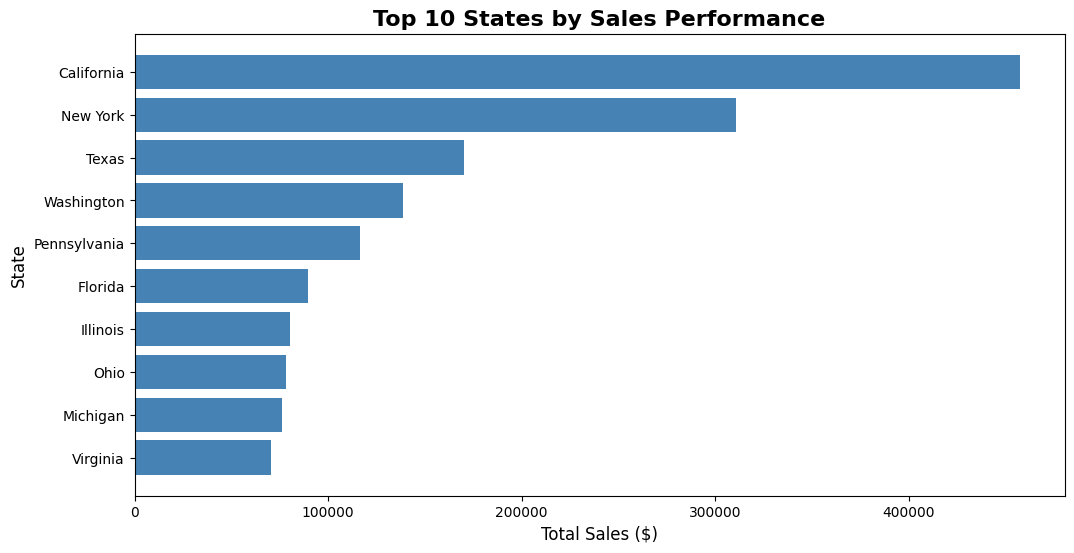

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

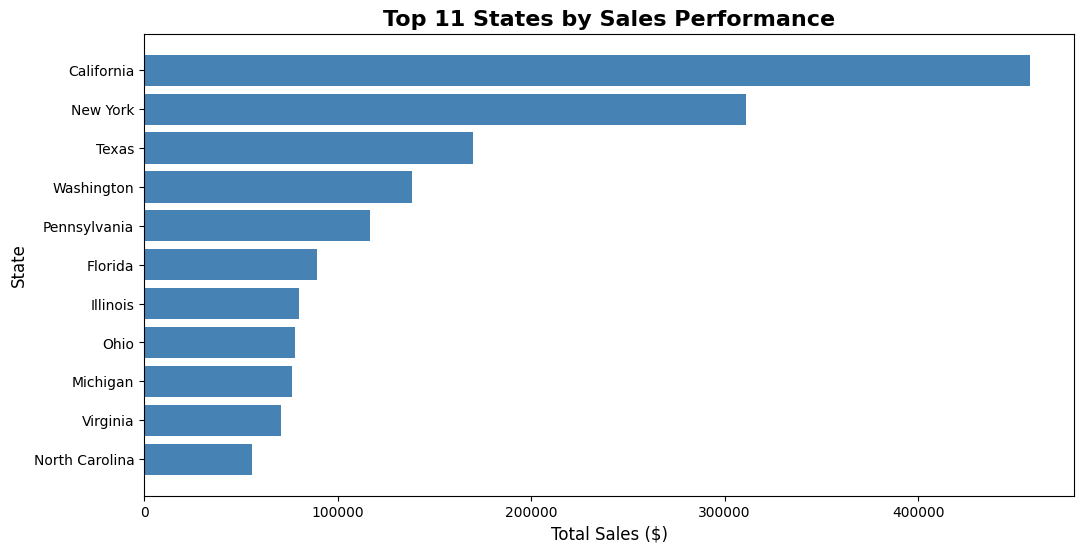

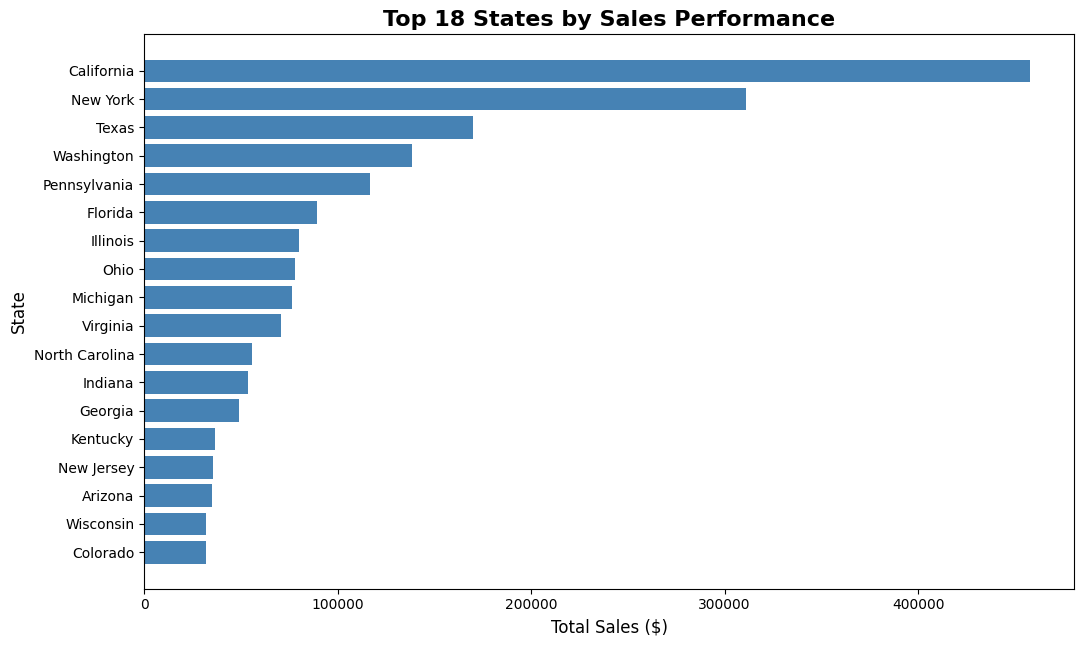

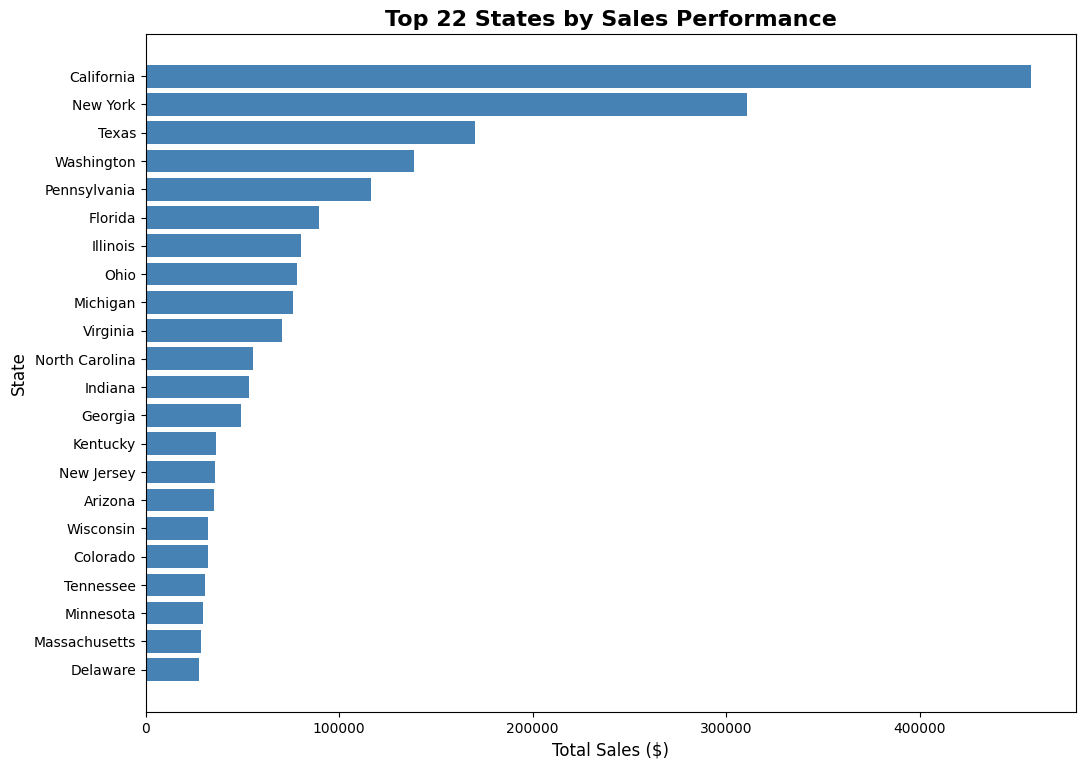

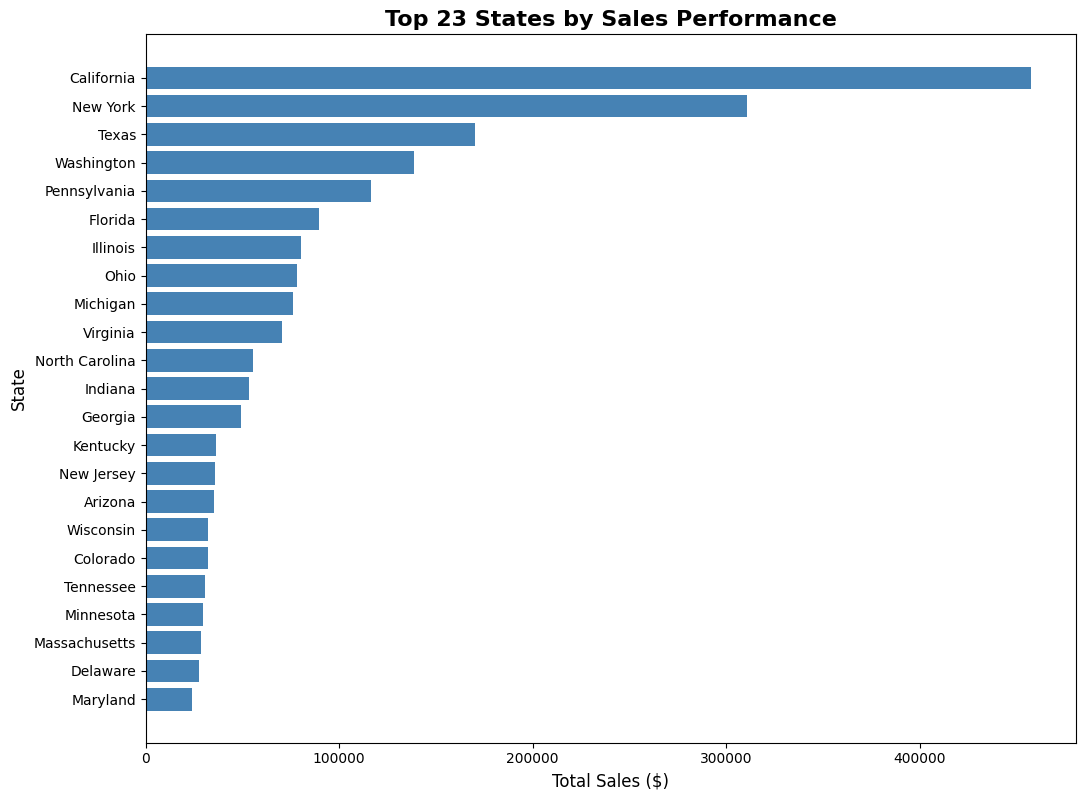

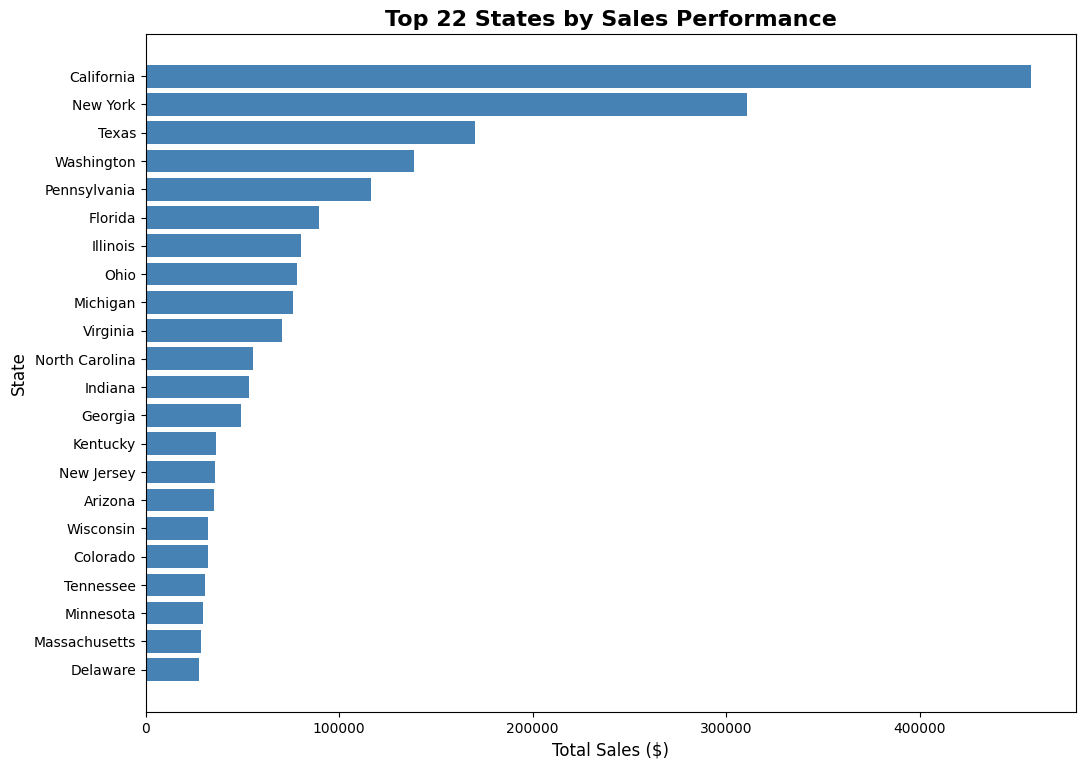

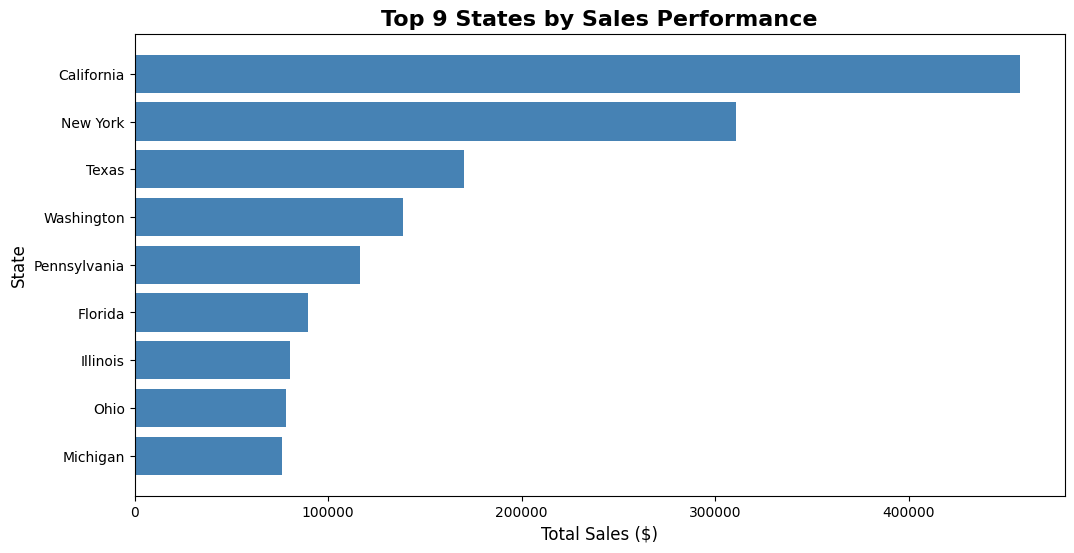

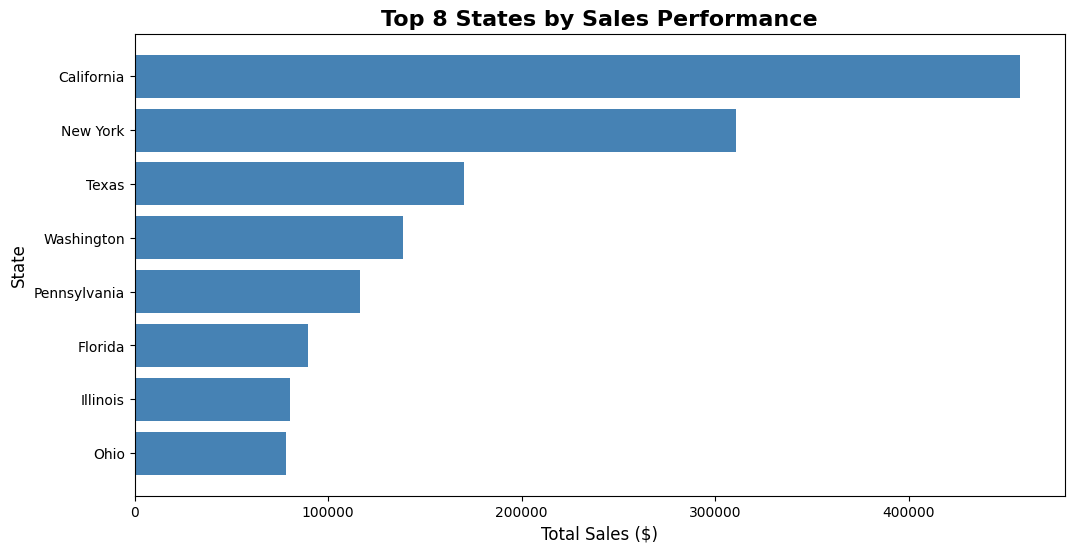

In [6]:
# Prepare geographic sales data
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

# Interactive geographic analysis
def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))

    # Get top N states
    top_states = state_sales.tail(top_n)

    # Create horizontal bar chart
    bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')

    # Add value labels on bars
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + max(top_states.values()) * 0.01, i, f'${value:,.0f}', 
                va='center', fontsize=10)

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Total states analyzed: {len(state_sales)}")
    print(f"Top {top_n} states represent: ${top_states.sum():,.0f} in sales")

# Create interactive slider
top_n_slider = widgets.IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);

## Communiquer des informations avec Seaborn

Cette section met en évidence les produits les plus rentables, puis analyse l'effet des remises sur le profit pour identifier les zones de risque.

In [ ]:
# Top 10 des produits les plus rentables
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis', orient='h')

plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + product_profit.values.max() * 0.01, i, f'${profit:,.0f}', 
            va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Key Insights:')
print(f'• Most profitable product generates: ${product_profit.iloc[0]:,.0f}')
print(f'• Top 10 products contribute: ${product_profit.sum():,.0f} total profit')
print(f'• Average profit per top product: ${product_profit.mean():,.0f}')

### Diagnostic de la remise face au profit

Le nuage de points permet d'identifier à partir de quel niveau de remise les profits se dégradent, et de comparer l'effet selon les catégories de produits.

In [ ]:
# Discount vs Profit Analysis
plt.figure(figsize=(14, 8))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Discount Strategy Analysis: Impact on Profitability by Category', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)
plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Discount Analysis Insights:')
high_discount = df[df['Discount'] > 0.2]
print(f'• Transactions with >20% discount: {len(high_discount):,}')
print(f'• Average profit for high discounts: ${high_discount["Profit"].mean():.2f}')
print(f'• Percentage of high-discount sales with losses: {(high_discount["Profit"] < 0).mean()*100:.1f}%')

print('\nCategory-specific discount impact:')
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc_cat = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc_cat) > 0:
        avg_loss = high_disc_cat['Profit'].mean()
        print(f'• {category}: Average profit at >20% discount = ${avg_loss:.2f}')

## Revue de la méthodologie et des outils

Matplotlib reste le meilleur choix pour un contrôle fin du rendu, des annotations exactes et l'intégration avec les widgets interactifs. Seaborn est plus rapide pour produire des graphiques statistiques élégants, avec des palettes automatiques, des légendes propres et des visuels adaptés à une présentation métier.

Recommandation : utiliser Matplotlib pour l'exploration rapide et les tableaux de bord interactifs, puis Seaborn pour la communication exécutive et les graphiques statistiques. 

In [ ]:
# Code to demonstrate library comparison
print('=== LIBRARY COMPARISON ANALYSIS ===')
print()

print('MATPLOTLIB STRENGTHS (from our analysis):')
print('• Fine-grained control over interactive widgets')
print('• Custom annotations and text positioning')
print('• Precise subplot layouts and figure sizing')
print('• Integration with ipywidgets for dynamic updates')
print()

print('SEABORN STRENGTHS (from our analysis):')
print('• Built-in statistical visualizations (regplot)')
print('• Automatic color palettes and legends')
print('• Clean, publication-ready default styling')
print('• Easy categorical data visualization')
print()

print('SPEED COMPARISON:')
import time

start = time.time()
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

start = time.time()
plt.figure(figsize=(8, 6))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(), x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f'• Matplotlib basic plot: {matplotlib_time:.4f} seconds')
print(f'• Seaborn equivalent: {seaborn_time:.4f} seconds')

## Résumé exécutif

Les ventes sont tirées par quelques produits et quelques États dominants, ce qui montre une concentration commerciale nette. Les remises élevées dégradent rapidement la rentabilité, surtout au-delà de 20 %. Enfin, la dynamique mensuelle confirme des variations temporelles utiles pour planifier les campagnes et ajuster les politiques de prix.

In [ ]:
# Generate automated insights for executive summary
print('=== EXECUTIVE SUMMARY - KEY FINDINGS ===')
print()

# Sales performance metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print('BUSINESS PERFORMANCE:')
print(f'• Total Revenue: ${total_sales:,.0f}')
print(f'• Total Profit: ${total_profit:,.0f}')
print(f'• Overall Profit Margin: {profit_margin:.1f}%')
print()

# Geographic insights
top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
print('GEOGRAPHIC PERFORMANCE:')
print(f'• Top performing state: {top_state} (${top_state_sales:,.0f})')
print(f'• Geographic concentration: Top 5 states = {(state_sales.tail(5).sum() / total_sales) * 100:.1f}% of sales')
print()

# Product insights
top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
print('PRODUCT PERFORMANCE:')
print(f'• Leading category: {top_category}')
print(f'• Most profitable product: {product_profit.index[0]}')
print()

# Discount insights
high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100
print('DISCOUNT STRATEGY INSIGHTS:')
print(f'• High discount risk: {high_discount_loss_rate:.1f}% of >20% discounts result in losses')
print('• Recommended max discount threshold: 20% to maintain profitability')